# Turner Angle: Global Front Analysis

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
import xarray as xr
import pandas as pd
from pathlib import Path
import json, re
from scipy.stats import gaussian_kde
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from fronts.properties.colocation import colocate_fronts_with_properties



plt.rcParams['figure.figsize'] = (16, 9)
plt.rcParams['font.size'] = 10
%matplotlib inline

print('Imports OK')

Imports OK


/home/lhoffma2/miniforge3/envs/fronts/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## 2. Load Pre-Computed Results

In [2]:
# ─── FILE PATHS ─── update these ───────────────────────────────────────────
results_dir  = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/group_fronts/v1/'          # directory with parquet / npy / json
coords_file  = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/coords/LLC_coords_lat_lon.nc'
ref_file     = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/derived/LLC4320_2012-11-09T12_00_00_gradb2_v1.nc'
run_tag      = 'v1_bin_A'  # run identifier for file naming
# ─────────────────────────────────────────────────────────────────────────────

# Extract timestamp from ref_file name
pattern = r'(\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2})'
match   = re.search(pattern, ref_file)
if not match:
    raise ValueError(f'Cannot extract timestamp from: {ref_file}')
time_str      = match.group(1).replace('_', ':')   # 2012-11-09T12:00:00
time_str_safe = match.group(1).replace('-', '').replace(':', '')  # 20121109T12_00_00
time_str_safe = re.sub(r'T(\d{2})(\d{2})(\d{2})', r'T\1_\2_\3',
                       time_str.replace('-','').replace(':',''), count=1)
print(f'Timestep: {time_str}  (safe: {time_str_safe})')

# Construct standard filenames with run_tag
metadata_file  = Path(results_dir) / f'metadata_{time_str_safe}_{run_tag}.json'
labeled_file   = Path(results_dir) / f'labeled_fronts_global_{time_str_safe}_{run_tag}.npy'
geometry_file  = Path(results_dir) / f'global_front_geometry_{time_str_safe}_{run_tag}.parquet'
coloc_file     = Path(results_dir) / f'front_properties_{time_str_safe}_{run_tag}.parquet'

# Load metadata
with open(metadata_file) as f:
    metadata = json.load(f)
downsample_factor = metadata.get('downsample_factor', None)
print(f"Shape: {metadata['shape']},  Fronts: {metadata['num_fronts']:,}")
if downsample_factor:
    print(f'  ⚠️  Downsampled ×{downsample_factor}')

# Load label map
labeled_global = np.load(labeled_file)
print(f'labeled_global: {labeled_global.shape}')

# Load geometric properties
df_global = pd.read_parquet(geometry_file)
print(f'df_global: {len(df_global):,} fronts × {len(df_global.columns)} cols')

# Load colocation (enriched properties)
df_coloc = pd.read_parquet(coloc_file)
print(f'df_coloc: {len(df_coloc):,} fronts × {len(df_coloc.columns)} cols')

# Merge geometric + colocation data on front label
df_enriched = df_global.merge(df_coloc, left_on='label', right_on='flabel', how='inner')
print(f'df_enriched: {len(df_enriched):,} fronts × {len(df_enriched.columns)} cols')
print(f'  Columns: {list(df_enriched.columns)[:10]}...')

# Load coordinates
ds_coords  = xr.open_dataset(coords_file)
lat_global = ds_coords['lat'].values if 'lat' in ds_coords else ds_coords['YC'].values
lon_global = ds_coords['lon'].values if 'lon' in ds_coords else ds_coords['XC'].values
ds_coords.close()
if downsample_factor:
    lat_global = lat_global[::downsample_factor, ::downsample_factor]
    lon_global = lon_global[::downsample_factor, ::downsample_factor]

# Roll arrays so columns run -180 → +180
sample_row  = lat_global.shape[0] // 2
min_lon_col = int(np.argmin(lon_global[sample_row, :]))
shift       = -min_lon_col
if min_lon_col != 0:
    print(f'Rolling by {shift} cols to align longitude axis')
    lon_global    = np.roll(lon_global,    shift, axis=1)
    lat_global    = np.roll(lat_global,    shift, axis=1)
    labeled_global = np.roll(labeled_global, shift, axis=1)
else:
    print('No rolling needed')

print(f'\n✓ Pre-computed results loaded.  Array shape: {labeled_global.shape}')

Timestep: 2012-11-09T12:00:00  (safe: 20121109T12_00_00)
Shape: [12960, 17280],  Fronts: 135,654
labeled_global: (12960, 17280)
df_global: 135,654 fronts × 19 cols
df_coloc: 135,654 fronts × 156 cols
df_enriched: 135,654 fronts × 175 cols
  Columns: ['label', 'name', 'time', 'npix_x', 'y0', 'y1', 'x0', 'x1', 'centroid_lat', 'centroid_lon']...
Rolling by -10464 cols to align longitude axis

✓ Pre-computed results loaded.  Array shape: (12960, 17280)


## 3. Load Physical Property Maps

In [13]:
properties_dir = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts/derived'
version        = '1'  
timestamp      = '2012-11-09T12_00_00'
property_names = ['gradb2', 'gradtheta2', 'gradeta2', 'gradsalt2', 'gradrho2', 'relative_vorticity', 'coriolis_f']
property_files = {name: (str(Path(properties_dir) / f'LLC4320_{timestamp}_{name}_v{version}.nc'), name) for name in property_names}

# Optional downsampling for display
downsample_factor = 1

In [14]:
import xarray as xr
from fronts.properties.colocation import _load_property_file

property_arrays = {}
for prop_name, src in property_files.items():
    arr = _load_property_file(src)          # handles .nc tuples, .npy, or arrays
    arr = arr.squeeze()                      # drop any singleton time/depth dims
    if downsample_factor:
        arr = arr[::downsample_factor, ::downsample_factor]
    if min_lon_col != 0:                     # same longitude roll as labeled array
        arr = np.roll(arr, shift, axis=1)
    property_arrays[prop_name] = arr
    src_label = src[0] if isinstance(src, (list, tuple)) else (
                    str(src) if not isinstance(src, np.ndarray) else '<array>')
    print(f"  {prop_name:25s}  shape={arr.shape}  "
          f"range=[{float(np.nanmin(arr)):.3g}, {float(np.nanmax(arr)):.3g}]")

print(f'\n✓ {len(property_arrays)} property arrays loaded and aligned')

  gradb2                     shape=(12960, 17280)  range=[4.79e-25, 1.58e-09]
  gradtheta2                 shape=(12960, 17280)  range=[2.95e-23, 1.43e-05]
  gradeta2                   shape=(12960, 17280)  range=[3.29e-21, 5.89e-05]
  gradsalt2                  shape=(12960, 17280)  range=[0, 2.57e-05]
  gradrho2                   shape=(12960, 17280)  range=[5.24e-21, 1.73e-05]
  relative_vorticity         shape=(12960, 17280)  range=[-0.00158, 0.00118]
  coriolis_f                 shape=(12960, 17280)  range=[-0.000146, 0.000139]

✓ 7 property arrays loaded and aligned


## 4. Turner Angle

In [15]:
from matplotlib.colors import LogNorm, TwoSlopeNorm
import numpy as np

# ─── SETTINGS ─────────────────────────────────────────────────────────────────
# Keys in property_arrays for the squared gradient magnitudes.
# Add these fields in Section 2 if not already present.
GRADT2_KEY   = 'gradtheta2'     # |∇T|²   (°C² m⁻²)
GRADS2_KEY   = 'gradsalt2'     # |∇S|²   (PSU² m⁻²)
GRADRHO2_KEY = 'gradrho2'   # |∇ρ|²   ((kg m⁻³)² m⁻²)
GRADB2_KEY   = 'gradb2'     # |∇b|²   already used in earlier sections

ALPHA = 2.0e-4   # thermal expansion coefficient  (°C⁻¹)
BETA  = 7.4e-4   # haline contraction coefficient (PSU⁻¹)
RHO0  = 1025.0   # reference density (kg m⁻³)

MAP_DS      = 4      # spatial downsample factor for the global map (1 = full res)
MAP_PCT     = 2      # clip top/bottom N % of values for the colorscale
N_TU_BINS   = 90     # Turner-angle bins (uniform, degrees)
N_GB2_BINS  = 100    # grad-b² bins (log-spaced)
TU_CMAP     = 'RdBu_r'
JPDF_CMAP   = 'Reds'

# ─── LOAD GRADIENT ARRAYS ─────────────────────────────────────────────────────
for _k in [GRADT2_KEY, GRADS2_KEY, GRADRHO2_KEY, GRADB2_KEY]:
    if _k not in property_arrays:
        raise KeyError(f"{_k!r} not in property_arrays — add it in Section 2.")

gradT2   = np.asarray(property_arrays[GRADT2_KEY],   dtype=np.float64)
gradS2   = np.asarray(property_arrays[GRADS2_KEY],   dtype=np.float64)
gradrho2 = np.asarray(property_arrays[GRADRHO2_KEY], dtype=np.float64)
gradb2   = np.asarray(property_arrays[GRADB2_KEY],   dtype=np.float64)


# ─── COMPUTE HORIZONTAL TURNER ANGLE ──────────────────────────────────────────
# Formula (from image):
#   Tu_h = arctan( ∇ρ·(α∇T + β∇S) / ∇ρ·(α∇T − β∇S) )
#
# Under the linear EOS  ∇ρ = ρ₀(−α∇T + β∇S), the dot products simplify exactly:
#
#   Numerator   = ∇ρ·(α∇T + β∇S) = ρ₀(β²|∇S|² − α²|∇T|²)
#                 [T·S cross terms cancel exactly]
#
#   Denominator = ∇ρ·(α∇T − β∇S) = −|∇ρ|²/ρ₀
#                 [follows from |∇ρ|² = ρ₀²(α²|∇T|² − 2αβ∇T·∇S + β²|∇S|²)]
#
# Only squared gradient magnitudes are needed — no vector components required.
#
# Sign convention (this formula):
#   Tu > 0  →  temperature-dominated front  (α|∇T| > β|∇S|)
#   Tu < 0  →  salinity-dominated front     (β|∇S| > α|∇T|)
#   Tu → ±90°  →  compensating T/S gradients (|∇ρ| → 0)
#   Tu  =  0   →  β²|∇S|² = α²|∇T|²

numer      = RHO0 * (BETA**2 * gradS2 - ALPHA**2 * gradT2)
denom = np.where(gradrho2 > 0, -gradrho2 / RHO0, np.nan)

# Mask pixels where |∇ρ| = 0 to avoid divide-by-zero
#denom      = -gradrho2 / RHO0
#safe_denom = np.where(gradrho2 > 0, denom, np.nan)

tu_rad = np.arctan(numer / denom)   # denom always ≤ 0, so range is (−π/2, π/2)
tu_deg = np.degrees(tu_rad)

print(f"\nTurner angle (°):  mean {np.nanmean(tu_deg):.1f}  "
      f"std {np.nanstd(tu_deg):.1f}  "
      f"[{np.nanpercentile(tu_deg, 0.5):.1f}, {np.nanpercentile(tu_deg, 99.5):.1f}]")



Turner angle (°):  mean -0.5  std 52.5  [-88.7, 89.9]


/home/lhoffma2/miniforge3/envs/fronts/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


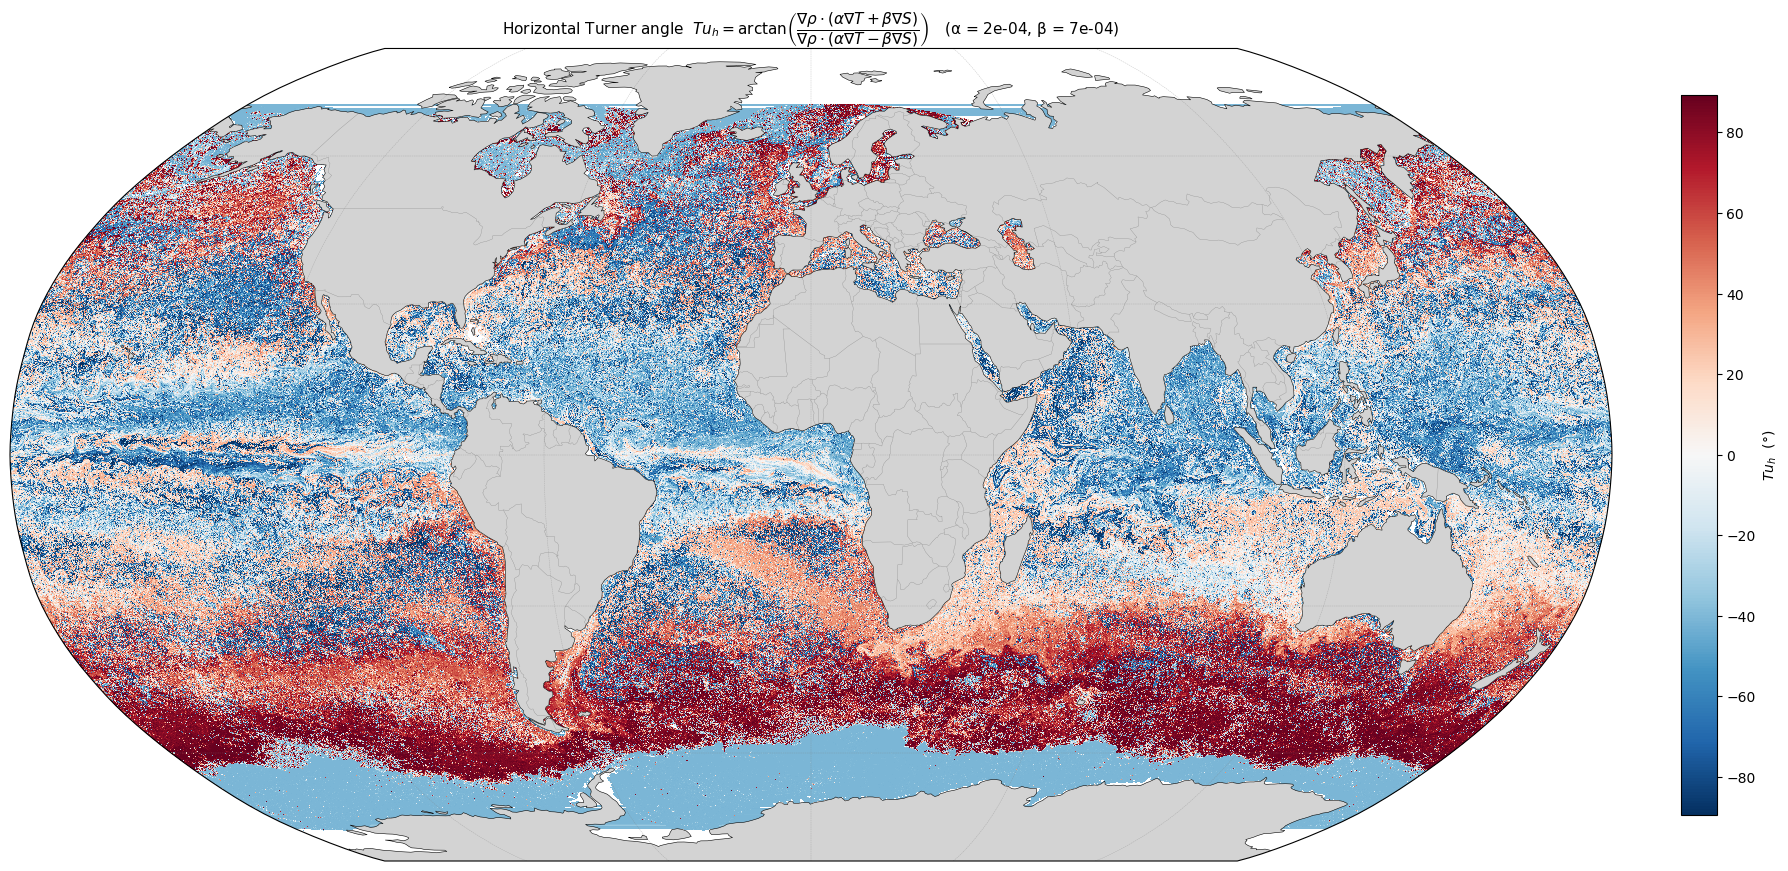

In [16]:

# ─── FIGURE 1: GLOBAL MAP (Cartopy) ───────────────────────────────────────────
ds    = MAP_DS
lat_p = lat_global[::ds, ::ds]
lon_p = lon_global[::ds, ::ds]
tu_p  = tu_deg[::ds, ::ds]

# Mask LLC4320 tile-boundary seams: rows/cols where adjacent lat or lon
# jumps by more than a threshold indicate a grid discontinuity
_dlat = np.abs(np.diff(lat_p, axis=0))
_dlon = np.abs(np.diff(lon_p, axis=0))
_seam = (_dlat > 5) | (_dlon > 90)         # True where a seam crosses
_seam_mask = np.zeros(tu_p.shape, dtype=bool)
_seam_mask[:-1, :] |= _seam
_seam_mask[1:,  :] |= _seam
tu_p = np.where(_seam_mask, np.nan, tu_p)  # blank out seam cells

_clip_lo = np.nanpercentile(tu_p, MAP_PCT)
_clip_hi = np.nanpercentile(tu_p, 100 - MAP_PCT)
_tu_abs  = max(abs(_clip_lo), abs(_clip_hi))

tfm = ccrs.PlateCarree()
fig1, ax1 = plt.subplots(figsize=(18, 9),
                          subplot_kw={'projection': ccrs.Robinson()})
ax1.set_global()

pm1 = ax1.pcolormesh(lon_p, lat_p, tu_p,
                     cmap=TU_CMAP, vmin=-_tu_abs, vmax=_tu_abs,
                     transform=tfm, shading='auto', rasterized=True)
plt.colorbar(pm1, ax=ax1, orientation='vertical',
             label=r'$Tu_h$  (°)',
             fraction=0.025, pad=0.04, shrink=0.85)

ax1.add_feature(cfeature.LAND,       facecolor='lightgray', zorder=2)
ax1.add_feature(cfeature.COASTLINE,  linewidth=0.4,  color='k',    zorder=3)
ax1.add_feature(cfeature.BORDERS,    linewidth=0.2,  color='gray', zorder=3)
ax1.gridlines(draw_labels=False, linewidth=0.3, color='gray',
              alpha=0.5, linestyle='--')

ax1.set_title(
    r'Horizontal Turner angle  '
    r'$Tu_h = \arctan\!\left(\dfrac{\nabla\rho\cdot(\alpha\nabla T+\beta\nabla S)}'
    r'{\nabla\rho\cdot(\alpha\nabla T-\beta\nabla S)}\right)$'
    f'   (α = {ALPHA:.0e}, β = {BETA:.0e})',
    fontsize=11, pad=10)
fig1.tight_layout()
plt.show()


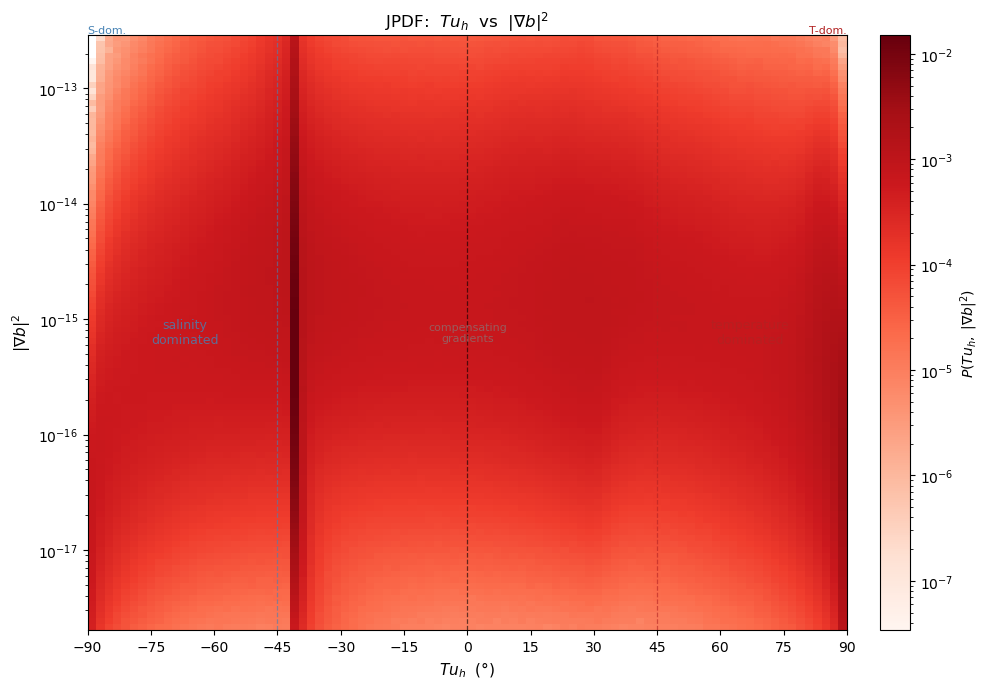

In [17]:
# Strict ocean mask: all four gradients must be strictly positive
# (zero-filled land pixels otherwise produce a spurious concentration)
ocean = (gradT2 > 0) & (gradS2 > 0) & (gradrho2 > 0) & (gradb2 > 0)
tu_deg_masked = np.where(ocean, tu_deg, np.nan)


# ─── FIGURE 2: JPDF  Turner angle vs. |∇b|² ──────────────────────────────────
# Use strict ocean mask to exclude land / fill-value pixels
_valid   = ocean & np.isfinite(tu_deg)
_tu_flat = tu_deg[_valid].ravel()
_gb_flat = gradb2[_valid].ravel()

# Uniform angle bins, log-spaced grad-b² bins
tu_edges  = np.linspace(-90, 90, N_TU_BINS + 1)
_gb_lo    = np.percentile(_gb_flat[_gb_flat > 0], 1)
_gb_hi    = np.percentile(_gb_flat[_gb_flat > 0], 99)
gb2_edges = np.logspace(np.log10(_gb_lo), np.log10(_gb_hi), N_GB2_BINS + 1)

counts, _, _ = np.histogram2d(_tu_flat, _gb_flat, bins=[tu_edges, gb2_edges])

# Normalise: ∬ P dTu d(log|∇b|²) = 1
dtu    = np.diff(tu_edges)[:, None]
dlog_g = np.diff(np.log(gb2_edges))[None, :]
pdf    = counts / (counts.sum() * dtu * dlog_g)

fig2, ax2 = plt.subplots(figsize=(10, 7))
_pmin = pdf[pdf > 0].min()
pm2 = ax2.pcolormesh(tu_edges, gb2_edges, pdf.T,
                     norm=LogNorm(vmin=_pmin, vmax=pdf.max()),
                     cmap=JPDF_CMAP, rasterized=True)
plt.colorbar(pm2, ax=ax2,
             label=r'$P(Tu_h,\;|\nabla b|^2)$',
             fraction=0.046, pad=0.04)

ax2.set_yscale('log')
ax2.set_xlim(-90, 90)
ax2.set_xticks(np.arange(-90, 91, 15))
ax2.set_xlabel(r'$Tu_h$  (°)', fontsize=11)
ax2.set_ylabel(r'$|\nabla b|^2$', fontsize=11)
ax2.set_title(r'JPDF:  $Tu_h$  vs  $|\nabla b|^2$', fontsize=12)

# Reference lines and region labels
_ymid = np.sqrt(gb2_edges[0] * gb2_edges[-1])
for _x, _lbl, _c in [(0, 'balanced', 'k'),
                      (45,  r'$\alpha|\nabla T|=\beta|\nabla S|$', 'firebrick'),
                      (-45, r'$\alpha|\nabla T|=\beta|\nabla S|$', 'steelblue')]:
    ax2.axvline(_x, color=_c, lw=0.9, ls='--', alpha=0.6)
ax2.text(-67, _ymid, 'salinity\ndominated',    color='steelblue',
         fontsize=9, ha='center', va='center', alpha=0.8)
ax2.text(+67, _ymid, 'temperature\ndominated', color='firebrick',
         fontsize=9, ha='center', va='center', alpha=0.8)
ax2.text( 0,  _ymid, 'compensating\ngradients', color='gray',
         fontsize=8, ha='center', va='center', alpha=0.65)
ax2.text(-90, gb2_edges[-1], 'S-dom.',   color='steelblue',
         fontsize=8, ha='left', va='bottom', clip_on=False)
ax2.text( 90, gb2_edges[-1], 'T-dom.',   color='firebrick',
         fontsize=8, ha='right', va='bottom', clip_on=False)

fig2.tight_layout()
plt.show()


## 5. Turner Angle on Co-located Fronts

In [18]:
from scipy.stats import binned_statistic_2d
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
import numpy as np

# ─── SETTINGS ─────────────────────────────────────────────────────────────────
GRADT2_KEY   = 'gradtheta2'    # base key in df_enriched (looks for _median, _mean, …)
GRADS2_KEY   = 'gradsalt2'
GRADRHO2_KEY = 'gradrho2'
GRADB2_KEY   = 'gradb2'

ALPHA = 2.0e-4
BETA  = 7.4e-4
RHO0  = 1025.0

TU_LAT_BINS  = 90     # 2° latitude  bins for the spatial map
TU_LON_BINS  = 180    # 2° longitude bins for the spatial map
N_TU_BINS    = 60     # Turner-angle bins for the JPDF
N_GB2_BINS   = 60     # grad-b² bins (log-spaced) for the JPDF
MAP_PCT      = 2      # clip top/bottom N % for map colorscale
TU_CMAP      = 'RdBu_r'
JPDF_CMAP    = 'Reds'

# ─── FIND COLUMNS IN df_enriched ──────────────────────────────────────────────
def _col(base, sfx=('_median', '_mean', '')):
    for s in sfx:
        if base + s in df_enriched.columns:
            return base + s
    return None

_t2col  = _col(GRADT2_KEY)
_s2col  = _col(GRADS2_KEY)
_r2col  = _col(GRADRHO2_KEY)
_g2col  = _col(GRADB2_KEY)

missing = [k for k, c in zip([GRADT2_KEY, GRADS2_KEY, GRADRHO2_KEY, GRADB2_KEY],
                               [_t2col, _s2col, _r2col, _g2col]) if c is None]
if missing:
    raise KeyError(
        f"Columns not found in df_enriched for: {missing}\n"
        f"Ensure these fields are listed in property_files (Section 2) "
        f"so they are co-located with the fronts.")

print(f"Using columns: {_t2col}, {_s2col}, {_r2col}, {_g2col}")

# ─── COMPUTE PER-FRONT TURNER ANGLE ───────────────────────────────────────────
# Same formula as the gridded cell: Tu_h = arctan(Num / Den)
#   Num = ρ₀ (β²|∇S|² − α²|∇T|²)
#   Den = −|∇ρ|²/ρ₀         (always ≤ 0)
# Only median values per front are used (one scalar per front).

_gt2 = df_enriched[_t2col].values.astype(np.float64)
_gs2 = df_enriched[_s2col].values.astype(np.float64)
_gr2 = df_enriched[_r2col].values.astype(np.float64)
_gb2 = df_enriched[_g2col].values.astype(np.float64)

_numer = RHO0 * (BETA**2 * _gs2 - ALPHA**2 * _gt2)
_denom = np.where(_gr2 > 0, -_gr2 / RHO0, np.nan)

_tu_rad = np.arctan(_numer / _denom)
_tu_deg = np.degrees(_tu_rad)

# Strict ocean mask: all four co-located median values must be positive
_ocean_fr = (_gt2 > 0) & (_gs2 > 0) & (_gr2 > 0) & (_gb2 > 0) & np.isfinite(_tu_deg)

_tu_deg = np.where(_ocean_fr, _tu_deg, np.nan)

print(f"Per-front Tu_h (°):  {np.nansum(_ocean_fr):,} valid fronts  |  "
      f"mean {np.nanmean(_tu_deg):.1f}  std {np.nanstd(_tu_deg):.1f}  "
      f"[{np.nanpercentile(_tu_deg, 0.5):.1f}, {np.nanpercentile(_tu_deg, 99.5):.1f}]")

# Add to df_enriched for downstream use
df_enriched['tu_h_deg'] = _tu_deg

# ─── SPATIAL BIN: mean Turner angle per lat/lon cell ──────────────────────────
_lat_fr = df_enriched['centroid_lat'].values
_lon_fr = df_enriched['centroid_lon'].values

_valid_map = np.isfinite(_tu_deg) & np.isfinite(_lat_fr) & np.isfinite(_lon_fr)

tu_grid, lat_edges, lon_edges, _ = binned_statistic_2d(
    _lat_fr[_valid_map], _lon_fr[_valid_map], _tu_deg[_valid_map],
    statistic='mean',
    bins=[TU_LAT_BINS, TU_LON_BINS],
    range=[[-90, 90], [-180, 180]],
)
# tu_grid shape: (TU_LAT_BINS, TU_LON_BINS)
# Count-mask: hide bins with only 1 front (unreliable mean)
_cnt, _, _, _ = binned_statistic_2d(
    _lat_fr[_valid_map], _lon_fr[_valid_map], _tu_deg[_valid_map],
    statistic='count',
    bins=[TU_LAT_BINS, TU_LON_BINS],
    range=[[-90, 90], [-180, 180]],
)
tu_grid = np.where(_cnt >= 2, tu_grid, np.nan)

print(f"Spatial map: {np.isfinite(tu_grid).sum()} populated bins  "
      f"(min {int(_cnt[_cnt > 0].min())} / max {int(_cnt.max())} fronts per bin)")

Using columns: gradtheta2_median, gradsalt2_median, gradrho2_median, gradb2_median
Per-front Tu_h (°):  135,654 valid fronts  |  mean 2.3  std 48.6  [-78.6, 89.1]
Spatial map: 9904 populated bins  (min 1 / max 51 fronts per bin)


/home/lhoffma2/miniforge3/envs/fronts/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


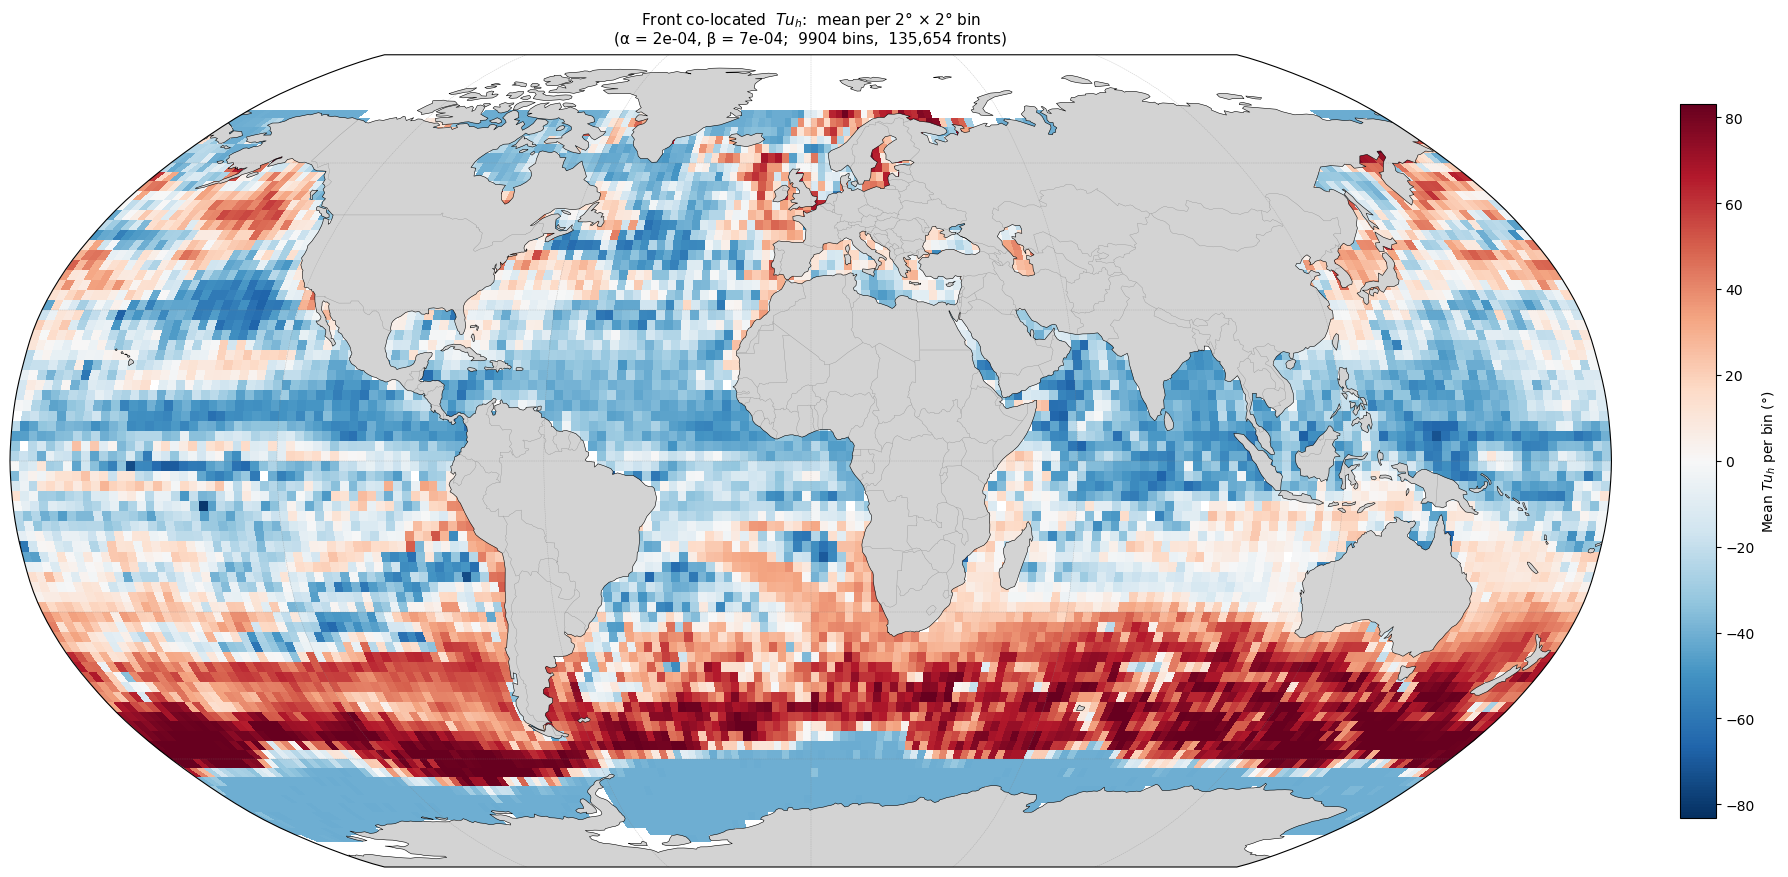


JPDF: 135,654 fronts


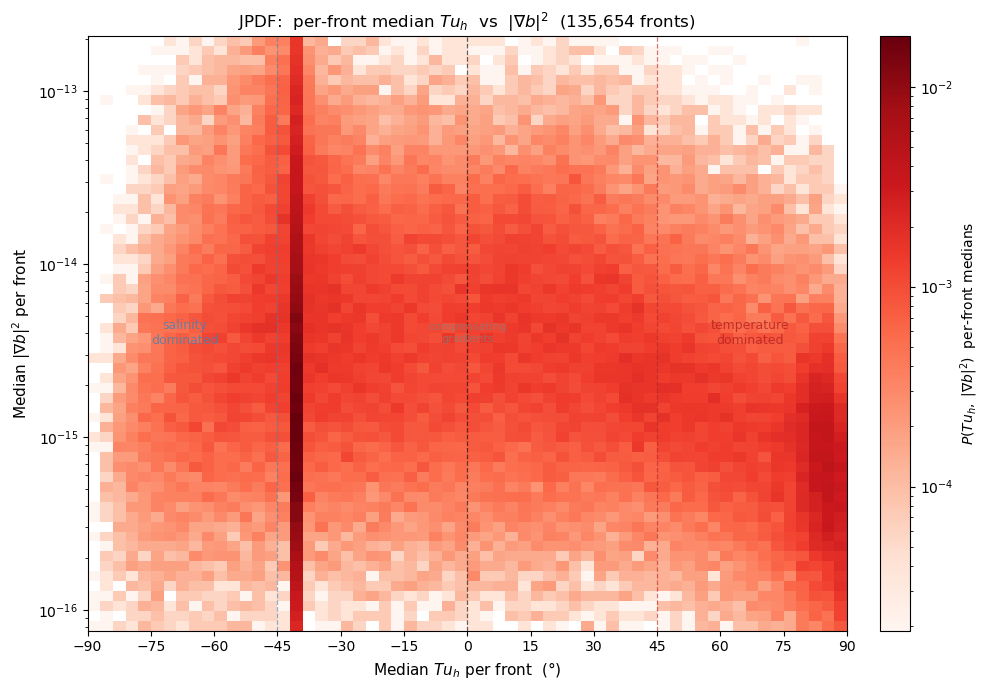

In [19]:

# ─── FIGURE 1: FRONT-COLOCATED MAP (Cartopy) ──────────────────────────────────
_clip = max(abs(np.nanpercentile(tu_grid, MAP_PCT)),
            abs(np.nanpercentile(tu_grid, 100 - MAP_PCT)))

tfm = ccrs.PlateCarree()
fig1, ax1 = plt.subplots(figsize=(18, 9),
                          subplot_kw={'projection': ccrs.Robinson()})
ax1.set_global()

# Use bin-edge arrays for pcolormesh so each cell aligns correctly
# lon_edges / lat_edges are (N+1,) vectors from binned_statistic_2d
pm1 = ax1.pcolormesh(lon_edges, lat_edges, tu_grid,
                     cmap=TU_CMAP, vmin=-_clip, vmax=_clip,
                     transform=tfm, shading='auto', rasterized=True)
plt.colorbar(pm1, ax=ax1, orientation='vertical',
             label=r'Mean $Tu_h$ per bin (°)',
             fraction=0.025, pad=0.04, shrink=0.85)

ax1.add_feature(cfeature.LAND,      facecolor='lightgray', zorder=2)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.4, color='k',    zorder=3)
ax1.add_feature(cfeature.BORDERS,   linewidth=0.2, color='gray', zorder=3)
ax1.gridlines(draw_labels=False, linewidth=0.3, color='gray',
              alpha=0.5, linestyle='--')
ax1.set_title(
    r'Front co-located  $Tu_h$:  mean per 2° × 2° bin'
    f'\n(α = {ALPHA:.0e}, β = {BETA:.0e};  '
    f'{np.isfinite(tu_grid).sum()} bins,  '
    f'{_valid_map.sum():,} fronts)',
    fontsize=11, pad=8)

fig1.tight_layout()
plt.show()

# ─── FIGURE 2: JPDF  per-front median Tu_h vs per-front median |∇b|² ─────────
_valid_jp = np.isfinite(_tu_deg) & np.isfinite(_gb2) & (_gb2 > 0)
_tu_jp    = _tu_deg[_valid_jp]
_gb_jp    = _gb2   [_valid_jp]

print(f"\nJPDF: {_valid_jp.sum():,} fronts")

tu_edges_j  = np.linspace(-90, 90, N_TU_BINS + 1)
_gb_lo       = np.percentile(_gb_jp[_gb_jp > 0], 1)
_gb_hi       = np.percentile(_gb_jp[_gb_jp > 0], 99)
gb2_edges_j  = np.logspace(np.log10(_gb_lo), np.log10(_gb_hi), N_GB2_BINS + 1)

counts_j, _, _ = np.histogram2d(_tu_jp, _gb_jp,
                                 bins=[tu_edges_j, gb2_edges_j])

# Normalise: ∬ P dTu d(log|∇b|²) = 1
dtu_j    = np.diff(tu_edges_j)[:, None]
dlog_g_j = np.diff(np.log(gb2_edges_j))[None, :]
pdf_j    = counts_j / (counts_j.sum() * dtu_j * dlog_g_j)

fig2, ax2 = plt.subplots(figsize=(10, 7))
_pmin_j = pdf_j[pdf_j > 0].min()
pm2 = ax2.pcolormesh(tu_edges_j, gb2_edges_j, pdf_j.T,
                     norm=LogNorm(vmin=_pmin_j, vmax=pdf_j.max()),
                     cmap=JPDF_CMAP, rasterized=True)
plt.colorbar(pm2, ax=ax2,
             label=r'$P(Tu_h,\;|\nabla b|^2)$  per-front medians',
             fraction=0.046, pad=0.04)

ax2.set_yscale('log')
ax2.set_xlim(-90, 90)
ax2.set_xticks(np.arange(-90, 91, 15))
ax2.set_xlabel(r'Median $Tu_h$ per front  (°)', fontsize=11)
ax2.set_ylabel(r'Median $|\nabla b|^2$ per front', fontsize=11)
ax2.set_title(
    r'JPDF:  per-front median $Tu_h$  vs  $|\nabla b|^2$'
    f'  ({_valid_jp.sum():,} fronts)',
    fontsize=12)

_ymid = np.sqrt(gb2_edges_j[0] * gb2_edges_j[-1])
for _x, _c in [(0, 'k'), (45, 'firebrick'), (-45, 'steelblue')]:
    ax2.axvline(_x, color=_c, lw=0.9, ls='--', alpha=0.6)
ax2.text(-67, _ymid, 'salinity\ndominated',    color='steelblue',
         fontsize=9, ha='center', va='center', alpha=0.8)
ax2.text(+67, _ymid, 'temperature\ndominated', color='firebrick',
         fontsize=9, ha='center', va='center', alpha=0.8)
ax2.text(  0, _ymid, 'compensating\ngradients', color='gray',
         fontsize=8, ha='center', va='center', alpha=0.65)

fig2.tight_layout()
plt.show()
